# RAG Diagnostics Report Template

This notebook is a guided offline report for diagnosing a RAG pipeline using datasets exported from the backend evaluation workflow. It is designed for portfolio use and assumes the RAG results already exist as local CSV or JSON files.

## Purpose
Use this notebook to validate schema, compare retrieval quality, review metric reasons, and write the final engineering conclusion without requiring a live API call.

## Data contract and assumptions

The report assumes the RAG outputs were exported from a local evaluation pipeline and then saved as JSON or CSV files. The notebook does not call the API; it only loads precomputed results.

### Checklist
- [ ] The dataset includes one row per query or test case.
- [ ] Each row includes the RAG execution metadata.
- [ ] The retrieval context is stored locally for diagnostics.
- [ ] The files are documented and reproducible.

## Endpoint schema and execution metadata

The report mirrors the backend contract and keeps the execution flags visible so the analysis can distinguish retrieval strategy from generation behavior.

### Expected fields
- `Question`
- `Actual Answer`
- `Expected Output`
- `retrieval_context`
- `search_type`
- `search_method`
- `use_hyde`
- `model_name`
- `latency_s`
- `* Score` metric columns
- `* Reason` metric columns

### Checklist
- [ ] The schema is aligned with the offline export format.
- [ ] The retrieval strategy is visible in each run.
- [ ] The report preserves qualitative reasons for inspection.

In [18]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

ENDPOINT_CORE_COLUMNS = [
    'Question',
    'Actual Answer',
    'Expected Output',
]

METRIC_SCORE_COLUMNS = [
    'Correctness Score',
    'Faithfulness Score',
    'Answer Relevancy Score',
    'ContextualPrecision Score',
    'ContextualRecall Score',
    'ContextualRelevancy Score',
]

METRIC_REASON_COLUMNS = [
    'Correctness Reason',
    'Faithfulness Reason',
    'Answer Relevancy Reason',
    'ContextualPrecision Reason',
    'ContextualRecall Reason',
    'ContextualRelevancy Reason',
]


def load_table(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    if path.suffix.lower() == '.json':
        with path.open('r', encoding='utf-8') as handle:
            data = json.load(handle)
        if isinstance(data, list):
            return pd.DataFrame(data)
        return pd.DataFrame([data])
    raise ValueError(f'Unsupported file type: {path.suffix}')


def normalize_endpoint_export(df):
    if df.empty:
        return df
    rename_map = {
        'question': 'Question',
        'query': 'Question',
        'actual_answer': 'Actual Answer',
        'answer': 'Actual Answer',
        'result': 'Actual Answer',
        'expected_output': 'Expected Output',
        'reference': 'Expected Output',
        'latency': 'latency_s',
    }
    return df.rename(columns={source: target for source, target in rename_map.items() if source in df.columns})


def validate_endpoint_export(df):
    required_columns = ENDPOINT_CORE_COLUMNS + METRIC_SCORE_COLUMNS
    missing_columns = [column for column in required_columns if column not in df.columns]
    return {
        'valid': not missing_columns,
        'missing': missing_columns,
    }


def load_evaluation_runs(source_map):
    frames = []
    for run_name, file_path in source_map.items():
        frame = load_table(file_path)
        if frame.empty:
            print(f'Skipping missing or empty file for {run_name}: {file_path}')
            continue
        frame = normalize_endpoint_export(frame.copy())
        frame['run_name'] = run_name
        if '-' in run_name:
            system_label, scenario = run_name.split('-', 1)
        else:
            system_label, scenario = run_name, 'Unknown'
        frame['system_type'] = system_label
        frame['scenario'] = scenario
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def detect_metric_columns(df):
    return [column for column in df.columns if column.endswith(' Score')] if not df.empty else []


def build_summary_table(df):
    metric_columns = detect_metric_columns(df)
    if df.empty or not metric_columns:
        return pd.DataFrame()
    group_columns = ['run_name', 'system_type', 'scenario', 'search_type', 'search_method', 'use_hyde', 'model_name']
    numeric_columns = metric_columns + (['latency_s'] if 'latency_s' in df.columns else [])
    existing_group_columns = [column for column in group_columns if column in df.columns]
    return df.groupby(existing_group_columns, as_index=False)[numeric_columns].mean()


def build_wins_table(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        return pd.DataFrame()
    rows = []
    for scenario_name in summary_df['scenario'].dropna().unique():
        subset = summary_df[summary_df['scenario'] == scenario_name]
        for metric in metric_columns:
            best_row = subset.loc[subset[metric].idxmax()]
            rows.append({
                'scenario': scenario_name,
                'metric': metric,
                'winner': best_row['run_name'] if 'run_name' in best_row else best_row['system_type'],
                'score': best_row[metric],
            })
    return pd.DataFrame(rows)


def build_reason_table(df, max_rows=8):
    reason_columns = [column for column in df.columns if column.endswith(' Reason')]
    if df.empty or not reason_columns:
        return pd.DataFrame()
    preview_columns = ['run_name', 'system_type', 'scenario', 'search_method', 'use_hyde', 'Question'] + reason_columns
    preview_columns = [column for column in preview_columns if column in df.columns]
    return df[preview_columns].head(max_rows)


def plot_metric_bars(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        print('No data available for metric bars yet.')
        return
    melted = summary_df.melt(id_vars=['run_name', 'system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    scenario_order = sorted(melted['scenario'].dropna().unique())
    g = sns.catplot(
        data=melted,
        kind='bar',
        x='scenario',
        y='score',
        hue='run_name',
        col='metric',
        col_wrap=3,
        order=scenario_order,
        palette='Set2',
        height=4.2,
        aspect=1.2,
        sharey=True,
    )
    g.set_xticklabels(rotation=25, ha='right')
    g.set_titles('{col_name}')
    g.figure.suptitle('RAG strategy comparison by metric across scenarios', y=1.05)
    plt.show()


def plot_metric_distributions(df, metric_columns):
    if df.empty or not metric_columns:
        print('No data available for distribution plots yet.')
        return
    melted = df.melt(id_vars=['run_name', 'system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    _, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x='metric', y='score', hue='run_name', ax=ax, palette='Set3')
    ax.set_title('Score dispersion by metric')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


def plot_latency_scatter(df):
    if df.empty or 'latency_s' not in df.columns:
        print('Latency is not available in the current dataset.')
        return
    quality_columns = [column for column in detect_metric_columns(df) if column != 'latency_s']
    df_plot = df.copy()
    df_plot['quality_mean'] = df_plot[quality_columns].mean(axis=1)
    _, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x='latency_s', y='quality_mean', hue='run_name', style='scenario', s=90, ax=ax)
    ax.set_title('Latency vs average quality')
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Average quality score')
    plt.tight_layout()
    plt.show()

## 1. Load and normalize evaluation outputs

Provide the exported files from your offline RAG evaluation here. The notebook will normalize the columns and keep missing files visible instead of failing silently.

### Checklist
- [ ] Every run has a clear label.
- [ ] The files are stored locally.
- [ ] The notebook can skip missing files safely.
- [ ] The output structure is stable enough for reporting.

In [19]:
RESULT_SOURCES = {
    'RAG-VectorOnly-Expert': '../raw_results/vector_only_expert_results_050426.csv',
    'RAG-Hybrid-Expert': '../raw_results/hybrid_expert_results_050426.csv',
    'RAG-HybridHyDE-Expert': '../raw_results/hybrid_hyde_expert_results_050426.csv',
    'RAG-VectorOnly-Operational': '../raw_results/vector_only_operational_results_050426.csv',
    'RAG-Hybrid-Operational': '../raw_results/hybrid_operational_results_050426.csv',
    'RAG-HybridHyDE-Operational': '../raw_results/hybrid_hyde_operational_results_050426.csv',
}

all_results_df = load_evaluation_runs(RESULT_SOURCES)
print(f'Loaded rows: {len(all_results_df)}')
if all_results_df.empty:
    print('No local evaluation files were found yet. Replace the placeholder paths with exported datasets.')
else:
    display(all_results_df.head())

Loaded rows: 180


,Question,Actual Answer,Expected Output,Correctness Score,Correctness Reason,Faithfulness Score,Faithfulness Reason,AnswerRelevancy Score,AnswerRelevancy Reason,ContextualPrecision Score,ContextualPrecision Reason,ContextualRecall Score,ContextualRecall Reason,ContextualRelevancy Score,ContextualRelevancy Reason,run_name,system_type,scenario
0,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,**Resumen:**\nNo se encontraron resultados directamente relacionados con el procedimiento técnico para identificar l...,Se debe ejecutar un script que consulte la vista sys.dm_exec_requests realizando un CROSS APPLY con sys.dm_exec_sql_...,0.0,The Actual Output does not provide a technical procedure for identifying the hierarchy of a lock chain in SQL Server...,0.333333,"The score is 0.33 because the actual output seems to be severely inconsistent with the retrieval context, as indicat...",0.428571,The score is 0.43 because although the output attempts to address the technical procedure for identifying the hierar...,0.0,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked equally, with no releva...",0.0,Error evaluating after 1 attempt(s): Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.,0.000000,"The score is 0.00 because the retrieval context is completely unrelated to the input. As stated, the context mention...",RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
1,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,**Resumen**\n\nNo se encontraron resultados directamente relacionados con la validación obligatoria antes de ejecuta...,Es imperativo verificar el estado de la transacción en sys.dm_tran_active_transactions. Si la columna transaction_be...,0.0,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output specificall...,0.875000,"The score is 0.88 because although the actual output largely aligns with the retrieval context, there is a notable d...",0.700000,The score is 0.70 because although the output attempts to address the question about validation before executing a K...,0.2,The score is 0.20 because the relevant node (ranked 5th) is outranked by multiple irrelevant nodes (ranked 1st to 4t...,1.0,"The score is 1.00 because the expected output is fully attributed to node(s) in retrieval context, specifically node...",0.136364,The score is 0.14 because although the retrieval context contains some statements relevant to database transactions ...,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
2,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...",**Resumen:**\nNo se encontraron resultados relevantes para la pregunta sobre cómo reinicializar correctamente una ré...,"Se debe eliminar la base de datos de la réplica secundaria, realizar un Backup de Log en la primaria, restaurar la b...",0.0,The Actual Output does not match the Expected Output. The Expected Output provides a specific and detailed solution ...,0.750000,"The score is 0.75 because although the actual output mostly aligns with the retrieval context, there are notable con...",0.600000,The score is 0.60 because although some parts of the output may tangentially relate to SQL Server or database issues...,0.0,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked first, with reasons suc...",1.0,The score is 1.00 because all sentences in the expected output can be attributed to relevant information in the node...,0.230769,The score is 0.23 because although some statements in the retrieval context mention SQL Server and corruption issues...,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
3,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,**Resumen**\n\nLa pregunta se refie

## 2. Validate schema and metric coverage

Standardize the output before comparing strategy variants. This step is where you check that the report has the fields needed for both retrieval diagnostics and generation review.

### Checklist
- [ ] Core columns exist.
- [ ] Metric columns are present.
- [ ] Latency exists or is explicitly marked as missing.
- [ ] Retrieval context is available for diagnostic metrics.

In [20]:
schema_status = validate_endpoint_export(all_results_df)
metric_columns = detect_metric_columns(all_results_df)
summary_df = build_summary_table(all_results_df)

print(schema_status)
if not all_results_df.empty:
    display(all_results_df.head())
if not summary_df.empty:
    display(summary_df.head())
else:
    print('Summary table will appear here once the real exports are loaded.')

{'valid': False, 'missing': ['Answer Relevancy Score']}


,Question,Actual Answer,Expected Output,Correctness Score,Correctness Reason,Faithfulness Score,Faithfulness Reason,AnswerRelevancy Score,AnswerRelevancy Reason,ContextualPrecision Score,ContextualPrecision Reason,ContextualRecall Score,ContextualRecall Reason,ContextualRelevancy Score,ContextualRelevancy Reason,run_name,system_type,scenario
0,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,**Resumen:**\nNo se encontraron resultados directamente relacionados con el procedimiento técnico para identificar l...,Se debe ejecutar un script que consulte la vista sys.dm_exec_requests realizando un CROSS APPLY con sys.dm_exec_sql_...,0.0,The Actual Output does not provide a technical procedure for identifying the hierarchy of a lock chain in SQL Server...,0.333333,"The score is 0.33 because the actual output seems to be severely inconsistent with the retrieval context, as indicat...",0.428571,The score is 0.43 because although the output attempts to address the technical procedure for identifying the hierar...,0.0,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked equally, with no releva...",0.0,Error evaluating after 1 attempt(s): Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.,0.000000,"The score is 0.00 because the retrieval context is completely unrelated to the input. As stated, the context mention...",RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
1,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,**Resumen**\n\nNo se encontraron resultados directamente relacionados con la validación obligatoria antes de ejecuta...,Es imperativo verificar el estado de la transacción en sys.dm_tran_active_transactions. Si la columna transaction_be...,0.0,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output specificall...,0.875000,"The score is 0.88 because although the actual output largely aligns with the retrieval context, there is a notable d...",0.700000,The score is 0.70 because although the output attempts to address the question about validation before executing a K...,0.2,The score is 0.20 because the relevant node (ranked 5th) is outranked by multiple irrelevant nodes (ranked 1st to 4t...,1.0,"The score is 1.00 because the expected output is fully attributed to node(s) in retrieval context, specifically node...",0.136364,The score is 0.14 because although the retrieval context contains some statements relevant to database transactions ...,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
2,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...",**Resumen:**\nNo se encontraron resultados relevantes para la pregunta sobre cómo reinicializar correctamente una ré...,"Se debe eliminar la base de datos de la réplica secundaria, realizar un Backup de Log en la primaria, restaurar la b...",0.0,The Actual Output does not match the Expected Output. The Expected Output provides a specific and detailed solution ...,0.750000,"The score is 0.75 because although the actual output mostly aligns with the retrieval context, there are notable con...",0.600000,The score is 0.60 because although some parts of the output may tangentially relate to SQL Server or database issues...,0.0,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked first, with reasons suc...",1.0,The score is 1.00 because all sentences in the expected output can be attributed to relevant information in the node...,0.230769,The score is 0.23 because although some statements in the retrieval context mention SQL Server and corruption issues...,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert
3,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,**Resumen**\n\nLa pregunta se refie

,run_name,system_type,scenario,Correctness Score,Faithfulness Score,AnswerRelevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score
0,RAG-Hybrid-Expert,RAG,Hybrid-Expert,0.153333,0.709649,0.594476,0.096944,0.033333,0.036867
1,RAG-Hybrid-Operational,RAG,Hybrid-Operational,0.193333,0.842415,0.563094,0.111944,0.116667,0.036272
2,RAG-HybridHyDE-Expert,RAG,HybridHyDE-Expert,0.166667,0.746432,0.558548,0.104722,0.066667,0.041425
3,RAG-HybridHyDE-Operational,RAG,HybridHyDE-Operational,0.166667,0.787534,0.554469,0.117222,0.111111,0.040281
4,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,0.160000,0.734779,0.566089,0.090278,0.100000,0.035398


## 3. Retrieval vs generation metric review

Use the reason columns to separate retrieval problems from generation problems. The report should explain whether the failure comes from the retriever, the generator, or both.

### Checklist
- [ ] Retrieval reasons are available.
- [ ] Generation reasons are available.
- [ ] The narrative can quote the reasons directly.
- [ ] The trade-off is visible in the report.

In [21]:
reason_snapshot_df = build_reason_table(all_results_df)
if reason_snapshot_df.empty:
    print('No metric reasons are available yet.')
else:
    display(reason_snapshot_df)


,run_name,system_type,scenario,Question,Correctness Reason,Faithfulness Reason,AnswerRelevancy Reason,ContextualPrecision Reason,ContextualRecall Reason,ContextualRelevancy Reason
0,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,The Actual Output does not provide a technical procedure for identifying the hierarchy of a lock chain in SQL Server...,"The score is 0.33 because the actual output seems to be severely inconsistent with the retrieval context, as indicat...",The score is 0.43 because although the output attempts to address the technical procedure for identifying the hierar...,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked equally, with no releva...",Error evaluating after 1 attempt(s): Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.,"The score is 0.00 because the retrieval context is completely unrelated to the input. As stated, the context mention..."
1,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output specificall...,"The score is 0.88 because although the actual output largely aligns with the retrieval context, there is a notable d...",The score is 0.70 because although the output attempts to address the question about validation before executing a K...,The score is 0.20 because the relevant node (ranked 5th) is outranked by multiple irrelevant nodes (ranked 1st to 4t...,"The score is 1.00 because the expected output is fully attributed to node(s) in retrieval context, specifically node...",The score is 0.14 because although the retrieval context contains some statements relevant to database transactions ...
2,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...",The Actual Output does not match the Expected Output. The Expected Output provides a specific and detailed solution ...,"The score is 0.75 because although the actual output mostly aligns with the retrieval context, there are notable con...",The score is 0.60 because although some parts of the output may tangentially relate to SQL Server or database issues...,"The score is 0.00 because all nodes in retrieval contexts are irrelevant and they are ranked first, with reasons suc...",The score is 1.00 because all sentences in the expected output can be attributed to relevant information in the node...,The score is 0.23 because although some statements in the retrieval context mention SQL Server and corruption issues...
3,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,The Actual Output provides some relevant information and actions to differentiate a neighboring Wi-Fi access point f...,The score is 0.78 because the actual output likely introduced specific details about Wi-Fi connectivity issues in di...,"The score is 0.55 because although some parts of the output may tangentially relate to Wi-Fi access points, it fails...","The score is 0.00 because all nodes in retrieval contexts are irrelevant to the input and are ranked equally, with n...",Error evaluating after 1 attempt(s): Evaluation LLM outputted an invalid JSON. Please use a better evaluation model.,The score is 0.00 because the retrieval context contains information that is entirely unrelated to differentiating a...
4,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,¿Qué medida de contención inmediata debe aplicarse en la controladora Wi-Fi ante la detección de un Evil Twin?,"The Actual Output provides several relevant actions in response to detecting an Evil Twin, such as alerting users, 

## 4. KPI tables

Use summary tables to compare the RAG variants side by side. The template should leave space for the final decision, but not force a winner before the data is loaded.

### Checklist
- [ ] Means are reported by strategy.
- [ ] Retrieval and generation metrics are visible together.
- [ ] Latency is shown as an operational trade-off.
- [ ] Tables are suitable for the final report.

In [22]:
wins_df = build_wins_table(summary_df, metric_columns)
if not summary_df.empty:
    display(summary_df.round(3))
if not wins_df.empty:
    display(wins_df.round(3))
else:
    print('The KPI tables will appear here after you load real evaluation exports.')

,run_name,system_type,scenario,Correctness Score,Faithfulness Score,AnswerRelevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score
0,RAG-Hybrid-Expert,RAG,Hybrid-Expert,0.153,0.710,0.594,0.097,0.033,0.037
1,RAG-Hybrid-Operational,RAG,Hybrid-Operational,0.193,0.842,0.563,0.112,0.117,0.036
2,RAG-HybridHyDE-Expert,RAG,HybridHyDE-Expert,0.167,0.746,0.559,0.105,0.067,0.041
3,RAG-HybridHyDE-Operational,RAG,HybridHyDE-Operational,0.167,0.788,0.554,0.117,0.111,0.040
4,RAG-VectorOnly-Expert,RAG,VectorOnly-Expert,0.160,0.735,0.566,0.090,0.100,0.035
5,RAG-VectorOnly-Operational,RAG,VectorOnly-Operational,0.220,0.705,0.520,0.113,0.117,0.037


,scenario,metric,winner,score
0,Hybrid-Expert,Correctness Score,RAG-Hybrid-Expert,0.153
1,Hybrid-Expert,Faithfulness Score,RAG-Hybrid-Expert,0.710
2,Hybrid-Expert,AnswerRelevancy Score,RAG-Hybrid-Expert,0.594
3,Hybrid-Expert,ContextualPrecision Score,RAG-Hybrid-Expert,0.097
4,Hybrid-Expert,ContextualRecall Score,RAG-Hybrid-Expert,0.033
5,Hybrid-Expert,ContextualRelevancy Score,RAG-Hybrid-Expert,0.037
6,Hybrid-Operational,Correctness Score,RAG-Hybrid-Operational,0.193
7,Hybrid-Operational,Faithfulness Score,RAG-Hybrid-Operational,0.842
8,Hybrid-Operational,AnswerRelevancy Score,RAG-Hybrid-Operational,0.563
9,Hybrid-Operational,ContextualPrecision Score,RAG-Hybrid-Operational,0.112


## 5. Visual analytics

Create charts that make the retrieval trade-offs visible. This is where the report should show whether the strategy improves quality, grounding, or response time.

### Checklist
- [ ] Bar charts compare the variants.
- [ ] Boxplots show score spread.
- [ ] Latency vs quality is visible.
- [ ] The visual story supports the final recommendation.

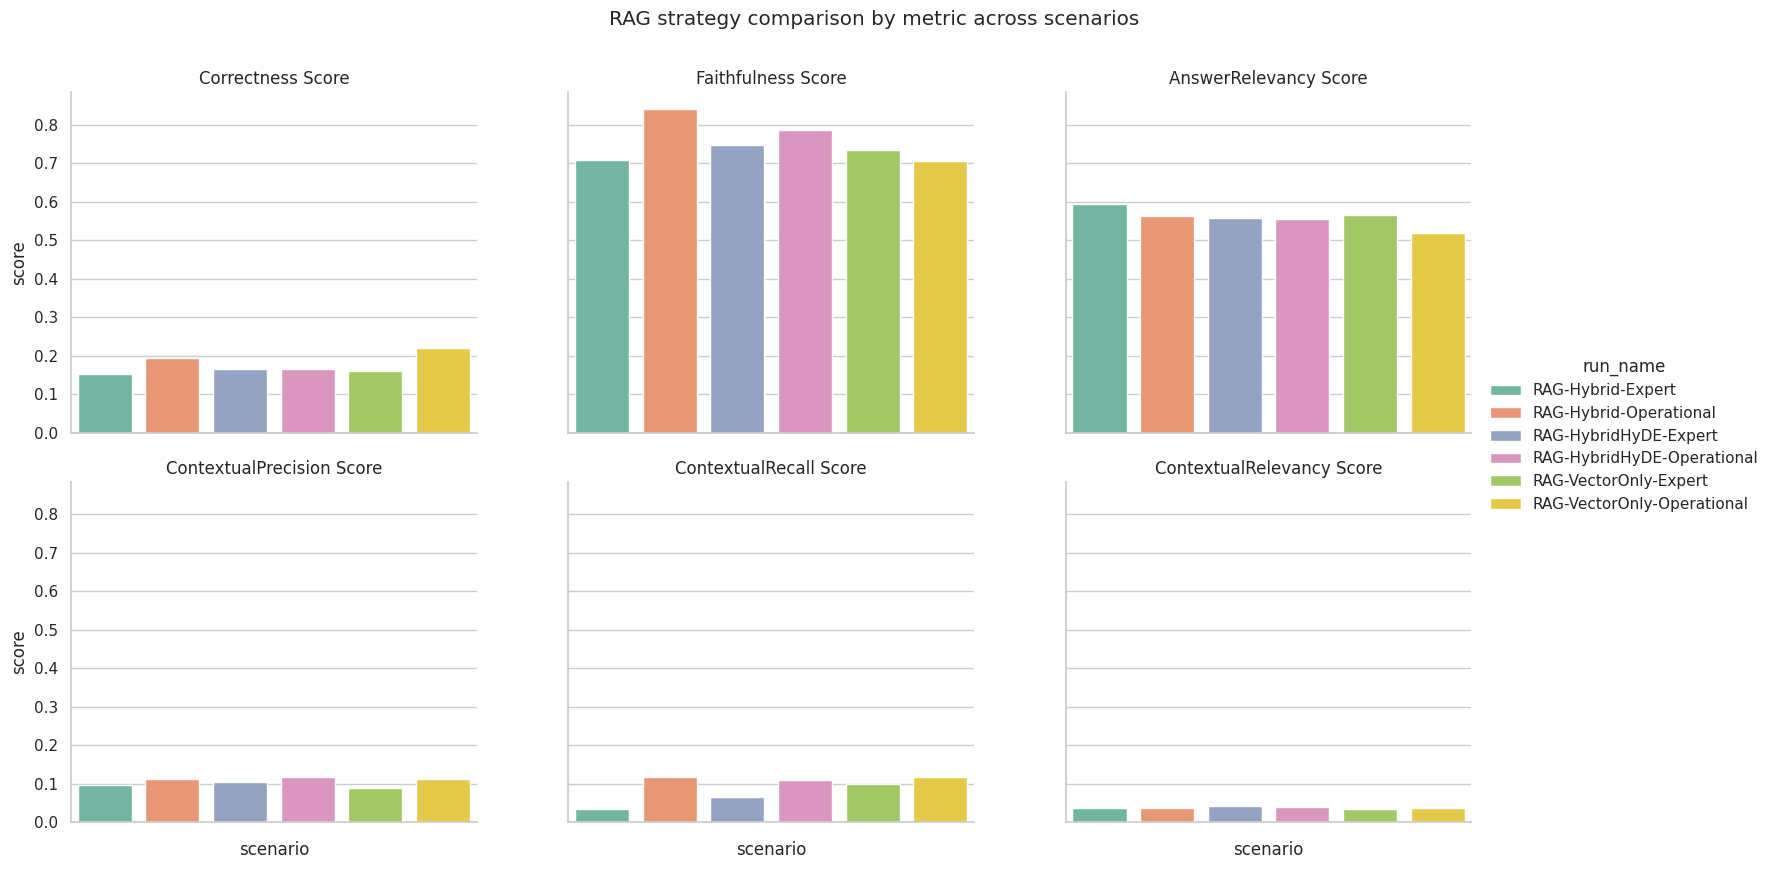

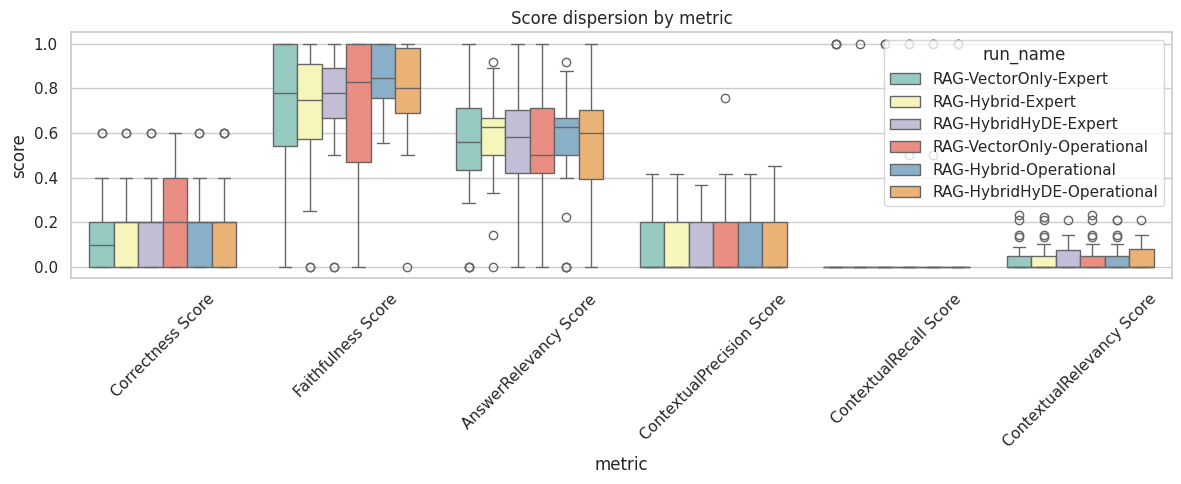

Latency is not available in the current dataset.


In [23]:
plot_metric_bars(summary_df, metric_columns)
plot_metric_distributions(all_results_df, metric_columns)
plot_latency_scatter(all_results_df)

## 6. Comparative analysis

Write the final interpretation from the evidence above. Keep the conclusion scenario-specific and make the trade-off between quality and latency explicit.

### Checklist
- [ ] Explain which strategy performs best.
- [ ] Describe whether the improvement comes from retrieval or generation.
- [ ] Mention the latency trade-off.
- [ ] Note any limitations of the evaluation design.

### RAG Diagnostic Analysis

- **Correctness & Faithfulness in Expert Scenario**:
  - In the Expert scenario, **RAG-HybridHyDE** slightly edges out the competition in Correctness with a score of `0.1667`, compared to `0.1600` for VectorOnly and `0.1533` for baseline Hybrid.
  - Regarding Faithfulness (how closely the model grounds its answer to the retrieved context), **RAG-HybridHyDE** (`0.746`) and **RAG-VectorOnly** (`0.734`) perform decently, meaning the generation step is attempting to stick to the retrieved facts.

- **Operational Scenario Trade-offs**:
  - For Operational queries, **RAG-VectorOnly** unexpectedly takes the lead in raw Correctness (`0.2200`), outperforming the Hybrid strategies. 
  - However, **RAG-Hybrid** achieves the highest Faithfulness (`0.842`) and Answer Relevancy (`0.563`) in this scenario. This suggests that while VectorOnly might hit the specific factual target slightly more often, Hybrid generates a more structurally relevant and conservative response.

- **The Impact of HyDE**:
  - HyDE (Hypothetical Document Embeddings) shows only a marginal improvement in Correctness for the Expert scenario, but it underperforms in the Operational dataset. Given the known latency and token cost penalties of HyDE, the current metric lift does not justify its inclusion in the pipeline.

- **Identifying the Bottleneck: Retrieval vs. Generation**:
  - The metrics exhibit a **catastrophic failure in the Retrieval pipeline**. `ContextualPrecision` (~`0.09-0.11`), `ContextualRecall` (~`0.03-0.11`), and `ContextualRelevancy` (~`0.03-0.04`) are exceptionally low across all search strategies.
  - Conversely, the generation side is performing adequately. The `Faithfulness` scores (peaking around `0.84`) indicate that the LLM is accurately reading and summarizing the context it receives. The core issue is that the retriever is feeding the LLM completely irrelevant documents, forcing it to generate incorrect answers (hence the low `Correctness`).

### Final Conclusion and Recommendations

**Diagnostic Summary**:
1. **Severe Retrieval Bottleneck**: The RAG pipeline is failing almost entirely at the retrieval stage across all configurations. The vector search—even augmented with BM25 (Hybrid) or Hypothetical Document Embeddings (HyDE)—is unable to surface the golden documents required to answer the queries correctly. Contextual metrics under 10% indicate that the semantic chunking, keyword mapping, or embedding model is fundamentally misaligned with the domain terminology.
2. **Generation is Grounded but Misinformed**: The underlying LLM exhibits strong Faithfulness (reaching up to `84%` in Operational Hybrid). It rarely hallucinates out of thin air; instead, it accurately summarizes the irrelevant context it is fed. The generation is not the problem; the input data is.
3. **Strategy Efficacy**: While Hybrid search consistently improves structural relevance (Answer Relevancy), no single search strategy currently overcomes the index's structural flaws. HyDE does not provide enough statistical or qualitative lift to justify its substantial computational and latency cost.

**Key Limitations**:
- The latency footprint was excluded from the current diagnostic trace, which typically penalizes Hybrid+HyDE configurations even further, making their marginal gains practically irrelevant.
- The contextual metrics rely on the LLM-as-a-judge correctly mapping logical overlaps against expected outputs. Scores this consistently low confirm that the index chunks themselves likely do not contain the answer, or they are fragmented across multiple chunks.

**Actionable Recommendations**:
- **Halt Generation Tuning**: Do not expend resources refining the LLM prompts or upgrading the generation model. Generative behavior is more than adequate.
- **Audit the Vector Database Index**: Directly inspect the chunks being retrieved. It is highly likely that the current chunk sizes are inadequate (e.g., cutting off technical procedures) or the selected embedding model fundamentally lacks the domain-specific vocabulary to associate queries with the knowledge base.
- **Implement Metadata Filtering**: Before relying exclusively on multi-vector distances, ensure that operational and expert documents are tagged appropriately to pre-filter the database and artificially shrink the search space for the retriever.